# Notebook 04: Credit Scoring Models

**Purpose:** Build and train four credit scoring models inside sklearn Pipelines, compare via stratified cross-validation, tune the best model, and save final artifacts.

## Model Selection Rationale

### Model 1: Logistic Regression
- **Regulatory preference:** Basel II/III and bank regulators globally prefer interpretable models. A credit committee can audit individual coefficients.
- **Interpretability:** Coefficients are directly interpretable in log-odds space. A coefficient of -0.02 on credit_bureau_score means each +1 point in bureau score reduces default log-odds by 0.02.
- **Baseline:** If a more complex model is not meaningfully better (ΔAUC < 0.02), the simpler model is preferred.
- **Regularization:** L2 penalty prevents overfitting on 3,036 rows.

### Model 2: XGBoost (Gradient Boosting)
- **Performance:** Industry benchmark for tabular credit data — consistently wins in credit risk competitions.
- **Missing value handling:** Natively handles NaN via learned default directions at each split.
- **Non-linearity:** Captures credit score plateau effects, interaction effects without manual feature crossing.
- **Scale invariance:** Tree splits use rank ordering → no StandardScaler needed.

### Model 3: LightGBM (Leaf-Wise Boosting)
- **Leaf-wise tree growth** vs. level-wise (XGBoost): finds highest-gain splits first, squeezing more signal from limited data
- **Histogram-based binning**: discretises continuous features into bins — a natural regularisation for small datasets
- **`num_leaves` controls complexity** directly without `max_depth` constraint: allows richer splits with explicit overfitting control
- **Faster**: 5–10× faster than XGBoost — enables more tuning trials with Optuna

### Model 4: Stacking Ensemble (LR + LGBM + XGB → meta-LR)
- **Exploits model complementarity**: Logistic Regression finds linear decision boundaries; boosting finds non-linear ones
- **Out-of-fold meta-features**: `StackingClassifier(cv=5)` generates meta-features without leakage; each fold's models train on other folds
- **Conservative meta-learner**: C=0.1 regularisation prevents meta-LR from memorising fold-specific trust patterns
- **Regulatory preference**: Stacking selected only if it beats LR by >0.02 AUC (Basel II/III interpretability preference)

### Why Not Neural Networks?
- 3,036 rows is too small — severe overfitting without massive regularization.
- Black-box nature conflicts with regulatory explainability requirements.
- Gradient boosting outperforms neural nets on tabular data of this size (Grinsztajn et al., 2022).

## Pipeline Architecture — Prevents Data Leakage

```
pipeline.fit(X_train):
   1. Imputer fits on X_train statistics only
   2. Scaler fits on X_train statistics only
   3. Encoder fits on X_train categories only
   4. Classifier trains on transformed X_train

pipeline.predict(X_test):
   1. Imputer uses TRAINING statistics (not test)
   2. Scaler uses TRAINING mean/std (not test)
   3. Encoder uses TRAINING categories
   → Mirrors exactly what happens in production
```

In [1]:
# ── CELL 1: Environment setup ──────────────────────────────────────────────────
import sys, os, json

try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/stanbic_sme_credit'
except ImportError:
    IN_COLAB = False
    _search = os.getcwd()
    BASE_PATH = _search
    for _ in range(3):
        if os.path.isdir(os.path.join(BASE_PATH, 'src')):
            break
        BASE_PATH = os.path.dirname(BASE_PATH)

sys.path.insert(0, os.path.join(BASE_PATH, 'src'))
env_str = 'Google Colab' if IN_COLAB else 'Local Jupyter'
print(f'Environment : {env_str}')
print(f'Base path   : {BASE_PATH}')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
import scipy.stats as st

# XGBoost
from xgboost import XGBClassifier

# LightGBM — typically outperforms XGBoost on small/imbalanced datasets:
# (1) native categorical support via LGBM_CATEGORICAL, (2) leaf-wise
# tree growth finds better splits with fewer leaves on small data,
# (3) histogram-based algorithm is less prone to overfitting with <5K rows
try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
    print('LightGBM available.')
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM not installed — run: pip install lightgbm')

# imbalanced-learn (SMOTE comparison)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from preprocessing import (
    NUMERIC_FEATURES, CATEGORICAL_FEATURES, BINARY_FEATURES,
    ALL_MODEL_FEATURES, TARGET
)

PROCESSED    = f'{BASE_PATH}/data/processed'
MODELS_PATH  = f'{BASE_PATH}/models'
FIGURES_PATH = f'{BASE_PATH}/reports/figures'
print('Environment ready.')
print(f'Feature counts: {len(NUMERIC_FEATURES)} numeric, '
      f'{len(CATEGORICAL_FEATURES)} categorical, {len(BINARY_FEATURES)} binary '
      f'= {len(ALL_MODEL_FEATURES)} total')

Mounted at /content/drive
Environment : Google Colab
Base path   : /content/drive/MyDrive/stanbic_sme_credit
LightGBM available.
Environment ready.
Feature counts: 24 numeric, 6 categorical, 11 binary = 41 total


In [2]:
# ── CELL 2: Load splits and metadata ──────────────────────────────────────────
X_train = pd.read_csv(f'{PROCESSED}/X_train.csv', index_col=0)
X_test  = pd.read_csv(f'{PROCESSED}/X_test.csv',  index_col=0)
y_train = pd.read_csv(f'{PROCESSED}/y_train.csv', index_col=0).squeeze('columns')
y_test  = pd.read_csv(f'{PROCESSED}/y_test.csv',  index_col=0).squeeze('columns')

# Replace any inf/-inf with NaN so SimpleImputer can fill them with median.
# Ratio features (collateral_coverage_ratio, momo_to_revenue_ratio, etc.) can
# produce np.inf when a denominator was 0 at feature-engineering time and that
# value was saved to CSV.  SimpleImputer only treats np.nan as missing — it
# passes inf through unchanged, which then breaks LightGBM's sklearn validation
# and makes StandardScaler produce NaN statistics (inf - inf = nan).
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan,  inplace=True)

n_inf_train = np.isinf(X_train.select_dtypes('number').values).sum()
print(f'Infinity values remaining in X_train after replacement: {n_inf_train}')

with open(f'{PROCESSED}/split_metadata.json') as f:
    meta = json.load(f)

SCALE_POS_WEIGHT = meta['scale_pos_weight']

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Training default rate: {y_train.mean():.2%}')
print(f'Test default rate:     {y_test.mean():.2%}')
print(f'scale_pos_weight:      {SCALE_POS_WEIGHT:.2f}')

Infinity values remaining in X_train after replacement: 0
X_train: (2429, 41)  |  X_test: (608, 41)
Training default rate: 13.26%
Test default rate:     13.32%
scale_pos_weight:      6.54


## Step 1: Build the sklearn Preprocessing Pipeline

**ColumnTransformer** applies different preprocessing to different column types:
- **Numeric:** Impute with median → StandardScaler (critical for Logistic Regression convergence)
- **Categorical:** Impute with 'Unknown' → OneHotEncoder
- **Binary:** Impute with 0 → pass through

**Why `handle_unknown='ignore'` in OneHotEncoder:**
At inference time, a new application might arrive with a sector not seen during training (e.g., a new business type). `ignore` maps it to all-zeros rather than raising an error — essential for production robustness.

**Why `sparse_output=False`:**
XGBoost's sklearn API works better with dense arrays. The dataset is small enough (3,036 rows) that memory is not a concern.

In [3]:
# ── CELL 3: Build the shared ColumnTransformer preprocessor ───────────────────
# v2: Categorical features use TargetEncoder instead of OneHotEncoder.
#
# WHY TargetEncoder over OneHotEncoder for credit risk:
#   OHE creates k-1 sparse binary columns — 'sector' alone produces ~9 columns.
#   Sparse binary columns tell the model "this applicant is in retail" but NOT
#   "retail businesses default at 18% vs agriculture at 9%." That default rate
#   IS the information the model needs. TargetEncoder replaces each category
#   value with its mean target rate from the training data (P(default | sector)).
#   This is standard practice in credit scorecards — equivalent to Weight-of-
#   Evidence (WOE) encoding used by Basel-era scoring systems.
#
# WHY no leakage with TargetEncoder inside a Pipeline:
#   sklearn's TargetEncoder uses internal cross-fitting (cv=5): the training
#   data is split into sub-folds; each sub-fold's categories are encoded using
#   the OTHER sub-folds' mean targets. This is identical in spirit to how
#   StackingClassifier avoids leakage with out-of-fold predictions.
#   At inference time, categories are encoded using the full training set means.
#
# WHY smooth='auto':
#   Categories with few observations get shrunk towards the global mean —
#   Bayesian shrinkage. A sector with only 3 loans cannot produce a reliable
#   default rate; 'auto' blends the sector rate with the global rate using a
#   sample-size-weighted shrinkage factor.
#
# WHY replace_inf_with_nan is imported from preprocessing (not defined here):
#   Functions defined inline in notebook cells live in __main__. When joblib
#   serialises a Pipeline containing FunctionTransformer(_replace_inf_with_nan)
#   it records the module path __main__._replace_inf_with_nan. On deserialisation
#   that path does not resolve → PicklingError. Moving the function to
#   preprocessing.py gives it a stable importable address so the Pipeline
#   can be saved and loaded correctly across sessions.

from sklearn.preprocessing import FunctionTransformer, TargetEncoder
from preprocessing import replace_inf_with_nan  # top-level module fn — pickle-safe

# Numeric branch: inf->NaN -> median impute -> StandardScaler
numeric_pipe = Pipeline([
    ('inf_to_nan', FunctionTransformer(replace_inf_with_nan, validate=False)),
    ('imputer',    SimpleImputer(strategy='median')),
    ('scaler',     StandardScaler())
])

# Categorical branch: impute with 'Unknown' -> TargetEncoder
# WHY still impute first: makes NaN -> 'Unknown' explicit and consistent.
# TargetEncoder maps unseen categories to the global mean at inference time.
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', TargetEncoder(smooth='auto', cv=5, random_state=42))
])

# Binary branch: impute with 0, pass through
binary_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])

preprocessor = ColumnTransformer([
    ('numeric',     numeric_pipe,     NUMERIC_FEATURES),
    ('categorical', categorical_pipe, CATEGORICAL_FEATURES),
    ('binary',      binary_pipe,      BINARY_FEATURES),
], remainder='drop')

print('ColumnTransformer preprocessor built (v2 — TargetEncoder for categoricals).')
print(f'  Numeric features:     {len(NUMERIC_FEATURES)}')
print(f'  Categorical features: {len(CATEGORICAL_FEATURES)}  (TargetEncoder: 1 float each, no OHE expansion)')
print(f'  Binary features:      {len(BINARY_FEATURES)}')
print(f'  Total output features: {len(ALL_MODEL_FEATURES)}')
print()
print('NOTE: TargetEncoder encodes each category as P(default | category).')
print('      This is the default-rate signal the model needs — not a sparse binary flag.')
print('NOTE: replace_inf_with_nan imported from preprocessing.py — pickle-safe.')

ColumnTransformer preprocessor built (v2 — TargetEncoder for categoricals).
  Numeric features:     24
  Categorical features: 6  (TargetEncoder: 1 float each, no OHE expansion)
  Binary features:      11
  Total output features: 41

NOTE: TargetEncoder encodes each category as P(default | category).
      This is the default-rate signal the model needs — not a sparse binary flag.
NOTE: replace_inf_with_nan imported from preprocessing.py — pickle-safe.


## Step 2: Cross-Validation Setup

**Why StratifiedKFold over KFold:**
Each fold must have the same class distribution as the full dataset. With KFold on imbalanced data, one fold might have 5% positives and another 25% — making CV scores unstable and misleading. StratifiedKFold guarantees ~15% defaults in every fold.

**Why 5 folds:**
- Each test fold has ~607 rows with ~91 positives
- AUC is roughly stable at 91 positives — borderline but acceptable
- 10 folds would give ~45 positives per fold — too few for stable AUC
- Larger folds = more training data per fold = better generalization estimates

In [4]:
# ── CELL 4: Cross-validation configuration ────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

SCORING = {
    'roc_auc':          'roc_auc',
    'average_precision': 'average_precision',  # PR-AUC
    'f1':               'f1',
    'precision':        'precision',
    'recall':           'recall',
}

# WHY AUC as primary metric:
# AUC is threshold-agnostic — measures discrimination at ALL thresholds.
# We will change the threshold in the Decision Engine (not use default 0.5).
# Optimising for F1 at threshold 0.5 is wrong when we know we'll use 0.25-0.55.

print('Cross-validation setup:')
print(f'  Strategy: StratifiedKFold (n_splits=5, shuffle=True, random_state=42)')
print(f'  Approx fold size: {len(X_train) // 5:,} rows')
print(f'  Approx positives per fold: {y_train.sum() // 5}')
print(f'  Metrics: {list(SCORING.keys())}')

Cross-validation setup:
  Strategy: StratifiedKFold (n_splits=5, shuffle=True, random_state=42)
  Approx fold size: 485 rows
  Approx positives per fold: 64
  Metrics: ['roc_auc', 'average_precision', 'f1', 'precision', 'recall']


## Step 3: Model 1 — Logistic Regression

In [5]:
# ── CELL 5: Logistic Regression pipeline ──────────────────────────────────────
# WHY class_weight='balanced':
# With default=15% imbalance, the model sees ~5.7 non-defaults per default.
# class_weight='balanced' reweights the loss function:
#   weight_class_i = n_samples / (n_classes * n_samples_class_i)
# This is equivalent to oversampling the minority class without the
# memory overhead or risk of synthetic sample artifacts.

# WHY C=1.0 as starting point:
# C = 1/lambda (inverse regularization strength).
# C=1.0 is the sklearn default — moderate regularization.
# We will tune this in hyperparameter search below.

# WHY solver='lbfgs':
# L-BFGS is a quasi-Newton optimizer — more memory efficient than Newton-CG,
# and faster than SGD for small-medium datasets (n < 10,000).
# Suitable for L2 regularization (our choice).

# WHY max_iter=1000:
# Default is 100, which often fails to converge after StandardScaler
# (even though scaling helps, complex boundaries need more iterations).

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        C=1.0,
        max_iter=1000,
        solver='lbfgs',
        random_state=42,
        n_jobs=-1
    ))
])

print('Logistic Regression pipeline built.')
print('Running 5-fold cross-validation...')

Logistic Regression pipeline built.
Running 5-fold cross-validation...


In [6]:
# ── CELL 6: LR cross-validation ───────────────────────────────────────────────
lr_cv = cross_validate(
    lr_pipeline, X_train, y_train,
    cv=cv, scoring=SCORING,
    return_train_score=True,
    n_jobs=-1
)

print('LOGISTIC REGRESSION — 5-Fold CV Results')
print('=' * 55)
for metric in SCORING:
    train_mean = lr_cv[f'train_{metric}'].mean()
    test_mean  = lr_cv[f'test_{metric}'].mean()
    test_std   = lr_cv[f'test_{metric}'].std()
    gap        = train_mean - test_mean
    flag       = '  ← OVERFIT?' if gap > 0.05 else ''
    print(f'  {metric:<20} Train: {train_mean:.4f}  |  Val: {test_mean:.4f} ± {test_std:.4f}  |  Gap: {gap:+.4f}{flag}')

lr_auc = lr_cv['test_roc_auc'].mean()
lr_gini = 2 * lr_auc - 1
print(f'\n  AUC-ROC: {lr_auc:.4f}  |  Gini: {lr_gini:.4f}')
print(f'  Gini interpretation: {"Excellent (>0.60)" if lr_gini > 0.60 else ("Good (0.40-0.60)" if lr_gini > 0.40 else "Below benchmark (<0.40)")}')

LOGISTIC REGRESSION — 5-Fold CV Results
  roc_auc              Train: 0.6615  |  Val: 0.5986 ± 0.0422  |  Gap: +0.0630  ← OVERFIT?
  average_precision    Train: 0.2441  |  Val: 0.2085 ± 0.0199  |  Gap: +0.0357
  f1                   Train: 0.2981  |  Val: 0.2672 ± 0.0253  |  Gap: +0.0310
  precision            Train: 0.2021  |  Val: 0.1814 ± 0.0140  |  Gap: +0.0207
  recall               Train: 0.5691  |  Val: 0.5097 ± 0.0747  |  Gap: +0.0594  ← OVERFIT?

  AUC-ROC: 0.5986  |  Gini: 0.1971
  Gini interpretation: Below benchmark (<0.40)


## Step 4: Model 2 — XGBoost (Gradient Boosting)

*Note: Model 3 (LightGBM) follows in Step 4b; Model 4 (Stacking Ensemble) in Step 7.*

In [7]:
# ── CELL 7: XGBoost pipeline ──────────────────────────────────────────────────
# NOTE: XGBoost does NOT need StandardScaler (tree-based, rank-invariant).
# But we keep the preprocessor for consistency — the scaler has no effect
# on tree-based models (monotonic transformations don't change split outcomes).
# Having one shared preprocessor makes the comparison fair (same imputation).

# v3: Stronger regularization from baseline — reduced overfitting gap observed in v2.
# Changes from v2:
#   n_estimators: 200 → 150   (fewer trees, less memorisation)
#   min_child_weight: 15 → 20  (more samples required per leaf)
#   reg_alpha: 0.5 → 1.0       (stronger L1 sparsity)
#   reg_lambda: 2.0 → 3.0      (stronger L2 shrinkage)
#   gamma: 0.1 → 0.2           (higher loss reduction threshold for splits)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        scale_pos_weight=SCALE_POS_WEIGHT,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=20,
        gamma=0.2,
        reg_alpha=1.0,
        reg_lambda=3.0,
        eval_metric='auc',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

print('XGBoost pipeline built (v3 — stronger baseline regularization).')
print('Running 5-fold cross-validation...')

XGBoost pipeline built (v3 — stronger baseline regularization).
Running 5-fold cross-validation...


In [8]:
# ── CELL 8: XGBoost cross-validation ──────────────────────────────────────────
xgb_cv = cross_validate(
    xgb_pipeline, X_train, y_train,
    cv=cv, scoring=SCORING,
    return_train_score=True,
    n_jobs=-1
)

print('XGBOOST — 5-Fold CV Results')
print('=' * 55)
for metric in SCORING:
    train_mean = xgb_cv[f'train_{metric}'].mean()
    test_mean  = xgb_cv[f'test_{metric}'].mean()
    test_std   = xgb_cv[f'test_{metric}'].std()
    gap        = train_mean - test_mean
    flag       = '  ← OVERFIT?' if gap > 0.05 else ''
    print(f'  {metric:<20} Train: {train_mean:.4f}  |  Val: {test_mean:.4f} ± {test_std:.4f}  |  Gap: {gap:+.4f}{flag}')

xgb_auc  = xgb_cv['test_roc_auc'].mean()
xgb_gini = 2 * xgb_auc - 1
print(f'\n  AUC-ROC: {xgb_auc:.4f}  |  Gini: {xgb_gini:.4f}')
print(f'  Gini interpretation: {"Excellent (>0.60)" if xgb_gini > 0.60 else ("Good (0.40-0.60)" if xgb_gini > 0.40 else "Below benchmark (<0.40)")}')

XGBOOST — 5-Fold CV Results
  roc_auc              Train: 0.8863  |  Val: 0.5983 ± 0.0346  |  Gap: +0.2880  ← OVERFIT?
  average_precision    Train: 0.5652  |  Val: 0.1995 ± 0.0231  |  Gap: +0.3658  ← OVERFIT?
  f1                   Train: 0.5304  |  Val: 0.2556 ± 0.0429  |  Gap: +0.2748  ← OVERFIT?
  precision            Train: 0.4056  |  Val: 0.1966 ± 0.0332  |  Gap: +0.2091  ← OVERFIT?
  recall               Train: 0.7670  |  Val: 0.3666 ± 0.0645  |  Gap: +0.4004  ← OVERFIT?

  AUC-ROC: 0.5983  |  Gini: 0.1965
  Gini interpretation: Below benchmark (<0.40)


## Step 4b: Model 3 — LightGBM

**Why LightGBM as an additional model:**
- **Leaf-wise tree growth** vs. XGBoost's level-wise: on small datasets, leaf-wise finds the highest-gain split first, squeezing more signal from limited data.
- **Histogram-based binning**: discretises continuous features into bins — a natural regularisation that reduces noise on small datasets.
- **`num_leaves` controls complexity** more directly than `max_depth`: allows rich splits with explicit overfitting control.
- **Faster**: 5-10× faster than XGBoost — allows more tuning iterations.

In [9]:
# ── CELL 8b: LightGBM pipeline ────────────────────────────────────────────────
if not LGBM_AVAILABLE:
    raise RuntimeError('pip install lightgbm  then restart the kernel.')

# v3: Stronger baseline regularization to reduce overfitting on 3K rows.
# Changes:
#   num_leaves: 15 → 12       (fewer leaves per tree)
#   min_child_samples: 20 → 25  (more samples required per leaf)
#   learning_rate: 0.03 → 0.02 (slower learning for stability)
#   reg_alpha: 0.1 → 0.5       (stronger L1 sparsity)
#   reg_lambda: 1.0 → 2.0      (stronger L2 shrinkage)

lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=300,
        max_depth=-1,           # uncapped depth; num_leaves controls complexity
        num_leaves=12,          # reduced from 15 for more regularization
        learning_rate=0.02,     # slower learning for stability
        class_weight='balanced',
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_samples=25,   # increased from 20 — stronger regularization
        reg_alpha=0.5,          # L1 regularisation
        reg_lambda=2.0,         # L2 regularisation
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

print('LightGBM pipeline built (v3 — stronger baseline regularization).')
print('Running 5-fold cross-validation...')

LightGBM pipeline built (v3 — stronger baseline regularization).
Running 5-fold cross-validation...


In [10]:
# ── CELL 8c: LightGBM cross-validation ───────────────────────────────────────
lgbm_cv = cross_validate(
    lgbm_pipeline, X_train, y_train,
    cv=cv, scoring=SCORING,
    return_train_score=True,
    n_jobs=-1
)

print('LIGHTGBM — 5-Fold CV Results')
print('=' * 55)
for metric in SCORING:
    train_mean = lgbm_cv[f'train_{metric}'].mean()
    test_mean  = lgbm_cv[f'test_{metric}'].mean()
    test_std   = lgbm_cv[f'test_{metric}'].std()
    gap        = train_mean - test_mean
    flag       = '  ← OVERFIT?' if gap > 0.05 else ''
    print(f'  {metric:<20} Train: {train_mean:.4f}  |  Val: {test_mean:.4f} ± {test_std:.4f}  |  Gap: {gap:+.4f}{flag}')

lgbm_auc  = lgbm_cv['test_roc_auc'].mean()
lgbm_gini = 2 * lgbm_auc - 1
print(f'\n  AUC-ROC: {lgbm_auc:.4f}  |  Gini: {lgbm_gini:.4f}')
print(f'  Gini: {"Excellent (>0.60)" if lgbm_gini > 0.60 else ("Good (0.40-0.60)" if lgbm_gini > 0.40 else "Below benchmark (<0.40)")}')

LIGHTGBM — 5-Fold CV Results
  roc_auc              Train: 0.9590  |  Val: 0.5925 ± 0.0302  |  Gap: +0.3665  ← OVERFIT?
  average_precision    Train: 0.7890  |  Val: 0.2115 ± 0.0289  |  Gap: +0.5775  ← OVERFIT?
  f1                   Train: 0.6920  |  Val: 0.2250 ± 0.0256  |  Gap: +0.4670  ← OVERFIT?
  precision            Train: 0.5595  |  Val: 0.1956 ± 0.0238  |  Gap: +0.3638  ← OVERFIT?
  recall               Train: 0.9068  |  Val: 0.2669 ± 0.0371  |  Gap: +0.6399  ← OVERFIT?

  AUC-ROC: 0.5925  |  Gini: 0.1851
  Gini: Below benchmark (<0.40)


In [11]:
# ── CELL 9: Three-way model comparison ────────────────────────────────────────
comparison = pd.DataFrame({
    'Metric': list(SCORING.keys()),
    'LR (val)':   [lr_cv[f'test_{m}'].mean()   for m in SCORING],
    'XGB (val)':  [xgb_cv[f'test_{m}'].mean()  for m in SCORING],
    'LGBM (val)': [lgbm_cv[f'test_{m}'].mean() for m in SCORING] if LGBM_AVAILABLE else [float('nan')] * len(SCORING),
})
comparison['Best'] = comparison[['LR (val)', 'XGB (val)', 'LGBM (val)']].idxmax(axis=1)
comparison = comparison.round(4)

print('MODEL COMPARISON — 5-Fold CV (all three models)')
print(comparison.to_string(index=False))
print()

aucs = {'LR': lr_auc, 'XGB': xgb_auc}
if LGBM_AVAILABLE:
    aucs['LGBM'] = lgbm_auc

best_model_name = max(aucs, key=aucs.get)
print(f'AUC ranking: {sorted(aucs.items(), key=lambda x: -x[1])}')
print(f'Best CV model so far: {best_model_name} (AUC = {aucs[best_model_name]:.4f})')
print('Note: final selection happens after hyperparameter tuning and stacking in Step 7.')

MODEL COMPARISON — 5-Fold CV (all three models)
           Metric  LR (val)  XGB (val)  LGBM (val)       Best
          roc_auc    0.5986     0.5983      0.5925   LR (val)
average_precision    0.2085     0.1995      0.2115 LGBM (val)
               f1    0.2672     0.2556      0.2250   LR (val)
        precision    0.1814     0.1966      0.1956  XGB (val)
           recall    0.5097     0.3666      0.2669   LR (val)

AUC ranking: [('LR', np.float64(0.5985638326948406)), ('XGB', np.float64(0.5982511933312435)), ('LGBM', np.float64(0.5925258910502483))]
Best CV model so far: LR (AUC = 0.5986)
Note: final selection happens after hyperparameter tuning and stacking in Step 7.


## Step 5: SMOTE Comparison (Class Imbalance Alternative)

In [12]:
# ── CELL 10: SMOTE vs class_weight comparison ─────────────────────────────────
# WHY run this comparison:
# SMOTE creates synthetic minority samples by interpolating between
# existing minority samples in feature space. It may improve recall
# but at the cost of precision (more false positives).
# class_weight='balanced' reweights the loss function — simpler and
# carries no risk of unrealistic synthetic samples.
# We compare to make an evidence-based choice.

# WHY imblearn.Pipeline (not sklearn.Pipeline):
# SMOTE must ONLY run during training, not during validation/test.
# imblearn.Pipeline.fit() applies SMOTE; .predict() / .transform() does not.
# sklearn.Pipeline does not understand sampling steps.

# Build a preprocessor WITHOUT StandardScaler for SMOTE
# (SMOTE works on processed features; scaling first makes interpolation distances meaningful)
smote_lr_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(
        random_state=42,
        k_neighbors=5
        # WHY k=5: default value. k must be < minority samples in each fold.
        # With ~15% default rate in 80% of 3036 ≈ 365 positives per fold, k=5 is safe.
    )),
    ('classifier', LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs', random_state=42
        # No class_weight='balanced' — SMOTE handles imbalance instead
    ))
])

smote_cv = cross_validate(
    smote_lr_pipeline, X_train, y_train,
    cv=cv, scoring=SCORING,
    return_train_score=True
)

print('SMOTE vs class_weight COMPARISON (Logistic Regression):')
print('=' * 65)
for metric in SCORING:
    cw_val    = lr_cv[f'test_{metric}'].mean()
    smote_val = smote_cv[f'test_{metric}'].mean()
    winner    = 'SMOTE' if smote_val > cw_val else 'class_weight'
    print(f'  {metric:<20} class_weight: {cw_val:.4f}  |  SMOTE: {smote_val:.4f}  → {winner}')

SMOTE vs class_weight COMPARISON (Logistic Regression):
  roc_auc              class_weight: 0.5986  |  SMOTE: 0.5908  → class_weight
  average_precision    class_weight: 0.2085  |  SMOTE: 0.2109  → SMOTE
  f1                   class_weight: 0.2672  |  SMOTE: 0.2617  → class_weight
  precision            class_weight: 0.1814  |  SMOTE: 0.1757  → class_weight
  recall               class_weight: 0.5097  |  SMOTE: 0.5159  → SMOTE


## Step 6: Hyperparameter Tuning

**Why RandomizedSearchCV over GridSearchCV for XGBoost:**
GridSearch with 5 hyperparameters × 5 values each = 3,125 fits × 5 folds = 15,625 models. RandomizedSearchCV samples n_iter=50 random combinations — achieves near-optimal in ~6% of the compute. Empirically, random search finds solutions within 5% of grid search optimal (Bergstra & Bengio, 2012).

**Why tune on AUC (not F1):** AUC is threshold-agnostic. F1 at 0.5 is irrelevant when we'll calibrate the business threshold in the Decision Engine.

## Step 6b: LightGBM Hyperparameter Tuning

**Key LGBM regularisation parameters differ from XGBoost:** `num_leaves` (not `max_depth`) and `min_child_samples` are the primary levers on small data. We search them jointly with `learning_rate` to minimise the train-val gap.

In [13]:
# ── CELL 11b: LightGBM hyperparameter tuning with Optuna (TPE) ────────────────
# WHY Optuna over RandomizedSearchCV: TPE Bayesian optimiser concentrates trials
# in promising regions. 25 Optuna trials ≈ 100+ uniform random trials in
# effective coverage — sufficient when features carry the main discriminative signal.
#
# WHY narrow search bounds:
#   On 3K rows the winning region is already known: slow LR (0.01–0.08),
#   few leaves (8–31, equivalent to max_depth 3–5), high min_child_samples (20–60).
#   Searching outside these bounds wastes compute on regions that overfit.

if LGBM_AVAILABLE:
    try:
        import optuna
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
        import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    from sklearn.model_selection import cross_val_score

    def lgbm_objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 150, 350),
            'num_leaves':        trial.suggest_int('num_leaves', 8, 25),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 15, 50),
            'subsample':         trial.suggest_float('subsample', 0.7, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 0.01, 1.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 3.0, log=True),
        }
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', LGBMClassifier(
                **params, class_weight='balanced',
                random_state=42, n_jobs=-1, verbose=-1
            ))
        ])
        return cross_val_score(pipe, X_train, y_train, cv=cv,
                               scoring='roc_auc', n_jobs=-1).mean()

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    print('Starting Optuna TPE search for LightGBM (25 trials × 5 folds = 125 fits)...')
    study.optimize(lgbm_objective, n_trials=25, show_progress_bar=True)

    best_lgbm_params = study.best_params
    print(f'\nBest AUC (Optuna CV): {study.best_value:.4f}')
    print('Best params:')
    for k, v in best_lgbm_params.items():
        print(f'  {k}: {v}')

    _lgbm_best_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LGBMClassifier(
            **best_lgbm_params, class_weight='balanced',
            random_state=42, n_jobs=-1, verbose=-1
        ))
    ])
    _lgbm_best_pipe.fit(X_train, y_train)

    from types import SimpleNamespace
    lgbm_search = SimpleNamespace(
        best_estimator_=_lgbm_best_pipe,
        best_score_=study.best_value
    )
else:
    lgbm_search = None
    print('LightGBM not available — skipping tuning.')

Starting Optuna TPE search for LightGBM (25 trials × 5 folds = 125 fits)...


  0%|          | 0/25 [00:00<?, ?it/s]


Best AUC (Optuna CV): 0.6127
Best params:
  n_estimators: 270
  num_leaves: 20
  learning_rate: 0.010437335666720523
  min_child_samples: 49
  subsample: 0.9497327922401265
  colsample_bytree: 0.6849356442713105
  reg_alpha: 0.02310201887845294
  reg_lambda: 0.6945227129221505


*(Feature importance plots are generated at the end of the notebook after all models are trained — see Step 7.)*

In [14]:
# ── CELL 11: XGBoost hyperparameter search ────────────────────────────────────
# 15 iterations is sufficient when feature engineering carries the signal.
# Search bounds narrowed to the proven low-overfit region for 3K rows:
#   max_depth 2–3, min_child_weight 10–20, strong L2 regularisation.

xgb_param_dist = {
    'classifier__n_estimators':     st.randint(150, 300),
    'classifier__max_depth':        st.randint(2, 4),        # depth >3 overfits on 3K rows
    'classifier__learning_rate':    st.uniform(0.03, 0.10),  # [0.03, 0.13]
    'classifier__min_child_weight': st.randint(10, 25),
    'classifier__subsample':        st.uniform(0.7, 0.3),    # [0.70, 1.00]
    'classifier__colsample_bytree': st.uniform(0.7, 0.3),
    'classifier__gamma':            st.uniform(0.0, 0.2),
    'classifier__reg_alpha':        st.uniform(0.2, 0.8),    # L1 sparsity
    'classifier__reg_lambda':       st.uniform(1.5, 2.5),    # strong L2 for small data
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=15,           # 15 × 5 = 75 fits — focused search with tight bounds
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=0,
    refit=True
)

print('Starting XGBoost RandomizedSearchCV (15 iterations × 5 folds = 75 fits)...')
xgb_search.fit(X_train, y_train)

print(f'Best AUC (CV): {xgb_search.best_score_:.4f}')
print('Best params:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')

Starting XGBoost RandomizedSearchCV (15 iterations × 5 folds = 75 fits)...
Best AUC (CV): 0.6024
Best params:
  classifier__colsample_bytree: 0.7692681476866446
  classifier__gamma: 0.048205093205202346
  classifier__learning_rate: 0.09832635188254582
  classifier__max_depth: 3
  classifier__min_child_weight: 22
  classifier__n_estimators: 157
  classifier__reg_alpha: 0.22751081689217473
  classifier__reg_lambda: 3.7733010051969553
  classifier__subsample: 0.777633994480005


In [15]:
# ── CELL 12: LR hyperparameter tuning ─────────────────────────────────────────
# L2 only (liblinear is slower with L1 on this size; L2 is the correct prior
# for correlated credit features). 5 C values cover the useful range.

from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    'classifier__C':       [0.01, 0.1, 1.0, 10.0, 100.0],
    'classifier__penalty': ['l2'],
    'classifier__solver':  ['lbfgs'],
}

lr_grid = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=42
        ))
    ]),
    param_grid=lr_param_grid,
    cv=cv, scoring='roc_auc', n_jobs=-1, refit=True, verbose=0
)

print('Running GridSearchCV for Logistic Regression (5 C values × 5 folds = 25 fits)...')
lr_grid.fit(X_train, y_train)

print(f'Best AUC (CV): {lr_grid.best_score_:.4f}')
print(f'Best params: {lr_grid.best_params_}')

Running GridSearchCV for Logistic Regression (5 C values × 5 folds = 25 fits)...
Best AUC (CV): 0.6073
Best params: {'classifier__C': 100.0, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}


## Step 7: Train Final Models & Build Stacking Ensemble

**Stacking rationale:** LR finds linear decision boundaries; LGBM finds non-linear ones. A meta-learner trained on both models' out-of-fold predictions exploits complementarity. `StackingClassifier(cv=5)` generates meta-features without leakage automatically.

In [16]:
# ── CELL 13: Extract best individual models ───────────────────────────────────
# xgb_search, lr_grid, lgbm_search are all defined by this point.
best_xgb  = xgb_search.best_estimator_
best_lr   = lr_grid.best_estimator_
best_lgbm = lgbm_search.best_estimator_ if (LGBM_AVAILABLE and lgbm_search) else None

lr_train_auc  = roc_auc_score(y_train, best_lr.predict_proba(X_train)[:, 1])
xgb_train_auc = roc_auc_score(y_train, best_xgb.predict_proba(X_train)[:, 1])
print('FINAL MODELS — Training Set AUC (sanity check):')
print(f'  LR:   {lr_train_auc:.4f}')
print(f'  XGB:  {xgb_train_auc:.4f}')
if best_lgbm:
    lgbm_train_auc = roc_auc_score(y_train, best_lgbm.predict_proba(X_train)[:, 1])
    print(f'  LGBM: {lgbm_train_auc:.4f}')
print('NOTE: Train AUC >> CV AUC = overfitting. Evaluate on test set in notebook 05.')

FINAL MODELS — Training Set AUC (sanity check):
  LR:   0.6780
  XGB:  0.9272
  LGBM: 0.9413
NOTE: Train AUC >> CV AUC = overfitting. Evaluate on test set in notebook 05.


In [17]:
# ── CELL 13b: Stacking Ensemble (LR + LGBM + XGB -> meta-LR) ────────────────
# v2: All three base learners in the stack.
# n_jobs=-1 here (was n_jobs=1) — parallelises the 5-fold base-model fitting.
#
# WHY passthrough=False: TargetEncoder already encodes default-rate signal into
# the feature matrix; passing raw features to the meta-learner would duplicate
# information and increase meta-LR overfitting risk.
#
# WHY meta-learner C=0.1: meta-features are correlated (same training data).
# Strong regularisation prevents the meta-LR from memorising fold-specific trust.

if LGBM_AVAILABLE and best_lgbm:
    stacking_pipeline = StackingClassifier(
        estimators=[('lr', best_lr), ('lgbm', best_lgbm), ('xgb', best_xgb)],
        final_estimator=LogisticRegression(C=0.1, max_iter=1000, random_state=42),
        cv=5, stack_method='predict_proba', passthrough=False, n_jobs=-1
    )
    stack_cv = cross_validate(
        stacking_pipeline, X_train, y_train,
        cv=cv, scoring=SCORING, return_train_score=True, n_jobs=-1
    )
    stack_auc  = stack_cv['test_roc_auc'].mean()
    stack_gini = 2 * stack_auc - 1
    print('STACKING ENSEMBLE — 5-Fold CV')
    for metric in SCORING:
        print(f'  {metric:<20} {stack_cv[f"test_{metric}"].mean():.4f} +/- {stack_cv[f"test_{metric}"].std():.4f}')
    print(f'\n  AUC: {stack_auc:.4f}  Gini: {stack_gini:.4f}')
else:
    stack_auc = lr_grid.best_score_
    stacking_pipeline = None
    print('Stacking skipped (LightGBM not available).')

all_aucs = {'LR': lr_grid.best_score_, 'XGB': xgb_search.best_score_}
if LGBM_AVAILABLE and best_lgbm:
    all_aucs['LGBM']     = lgbm_search.best_score_
    all_aucs['Stacking'] = stack_auc

print('\nFINAL SUMMARY — CV AUC all models:')
for name, auc in sorted(all_aucs.items(), key=lambda x: -x[1]):
    print(f'  {name:<12} AUC={auc:.4f}  Gini={2*auc-1:.4f}')
best_final = max(all_aucs, key=all_aucs.get)
print(f'\nSelected: {best_final}')

STACKING ENSEMBLE — 5-Fold CV
  roc_auc              0.6176 +/- 0.0393
  average_precision    0.2186 +/- 0.0237
  f1                   0.0000 +/- 0.0000
  precision            0.0000 +/- 0.0000
  recall               0.0000 +/- 0.0000

  AUC: 0.6176  Gini: 0.2353

FINAL SUMMARY — CV AUC all models:
  Stacking     AUC=0.6176  Gini=0.2353
  LGBM         AUC=0.6127  Gini=0.2255
  LR           AUC=0.6073  Gini=0.2146
  XGB          AUC=0.6024  Gini=0.2048

Selected: Stacking


In [18]:
# ── CELL 14: Save all models and update model registry ───────────────────────
# This cell was missing from v1 — notebooks 05/06/07 all require saved .pkl files.
#
# WHY save all four models (not just the CV winner):
#   Notebook 05 evaluates each on the held-out test set independently.
#   The CV winner is the provisional selection; the test-set winner is final.
#   Keeping all four allows side-by-side comparison in notebook 07 (SHAP).
#
# Refit stacking on FULL training set here:
#   StackingClassifier.fit() with cv=5 internally does out-of-fold fitting
#   to generate meta-features, then fits the meta-learner on those meta-features.
#   This is NOT the same as cross_validate — fit() produces the deployable model.

import os
os.makedirs(MODELS_PATH, exist_ok=True)

# Refit stacking on full training set and save
if LGBM_AVAILABLE and stacking_pipeline is not None:
    print('Refitting stacking ensemble on full training set...')
    stacking_pipeline.fit(X_train, y_train)
    joblib.dump(stacking_pipeline, f'{MODELS_PATH}/stacking_v1.pkl')
    print('  Saved: stacking_v1.pkl')

joblib.dump(best_lr,  f'{MODELS_PATH}/logistic_regression_v1.pkl')
joblib.dump(best_xgb, f'{MODELS_PATH}/xgboost_v1.pkl')
print('  Saved: logistic_regression_v1.pkl')
print('  Saved: xgboost_v1.pkl')

if LGBM_AVAILABLE and best_lgbm:
    joblib.dump(best_lgbm, f'{MODELS_PATH}/lightgbm_v1.pkl')
    print('  Saved: lightgbm_v1.pkl')

# Map best_final name to model file stem
_name_map = {
    'Stacking': 'stacking_v1',
    'LGBM':     'lightgbm_v1',
    'LR':       'logistic_regression_v1',
    'XGB':      'xgboost_v1',
}

registry = {
    'logistic_regression_v1': {
        'cv_auc':     round(lr_grid.best_score_, 4),
        'cv_gini':    round(2 * lr_grid.best_score_ - 1, 4),
        'best_params': lr_grid.best_params_,
    },
    'xgboost_v1': {
        'cv_auc':  round(xgb_search.best_score_, 4),
        'cv_gini': round(2 * xgb_search.best_score_ - 1, 4),
    },
}
if LGBM_AVAILABLE and best_lgbm:
    registry['lightgbm_v1'] = {
        'cv_auc':  round(lgbm_search.best_score_, 4),
        'cv_gini': round(2 * lgbm_search.best_score_ - 1, 4),
    }
if LGBM_AVAILABLE and stacking_pipeline is not None:
    registry['stacking_v1'] = {
        'cv_auc':       round(stack_auc, 4),
        'cv_gini':      round(stack_gini, 4),
        'base_models':  ['logistic_regression', 'lightgbm', 'xgboost'],
        'meta_learner': 'LogisticRegression(C=0.1)',
    }

registry['winning_model'] = _name_map.get(best_final, 'logistic_regression_v1')

import json as _json
with open(f'{MODELS_PATH}/model_registry.json', 'w') as f:
    _json.dump(registry, f, indent=2)

print()
print('MODELS TRAINED — v3 (4 total):')
print(f'  Model 1: Logistic Regression')
print(f'           CV AUC={lr_grid.best_score_:.4f}, best C={lr_grid.best_params_["classifier__C"]}')
print(f'  Model 2: XGBoost')
print(f'           CV AUC={xgb_search.best_score_:.4f}, scale_pos_weight={SCALE_POS_WEIGHT:.2f}')
if LGBM_AVAILABLE and best_lgbm:
    best_num_leaves = best_lgbm_params.get('num_leaves', '?')
    print(f'  Model 3: LightGBM')
    print(f'           CV AUC={lgbm_search.best_score_:.4f}, num_leaves={best_num_leaves}')
if LGBM_AVAILABLE and stacking_pipeline is not None:
    print(f'  Model 4: Stacking Ensemble (LR + LGBM + XGB → meta-LR C=0.1)')
    print(f'           CV AUC={stack_auc:.4f}')
print()
print(f'Saved: model_registry.json')
print(f'Provisional winner (CV): {registry["winning_model"]}')
print('Proceed to notebook 05_evaluation.ipynb — test set determines final winner.')

Refitting stacking ensemble on full training set...
  Saved: stacking_v1.pkl
  Saved: logistic_regression_v1.pkl
  Saved: xgboost_v1.pkl
  Saved: lightgbm_v1.pkl

MODELS TRAINED — v3 (4 total):
  Model 1: Logistic Regression
           CV AUC=0.6073, best C=100.0
  Model 2: XGBoost
           CV AUC=0.6024, scale_pos_weight=6.54
  Model 3: LightGBM
           CV AUC=0.6127, num_leaves=20
  Model 4: Stacking Ensemble (LR + LGBM + XGB → meta-LR C=0.1)
           CV AUC=0.6176

Saved: model_registry.json
Provisional winner (CV): stacking_v1
Proceed to notebook 05_evaluation.ipynb — test set determines final winner.


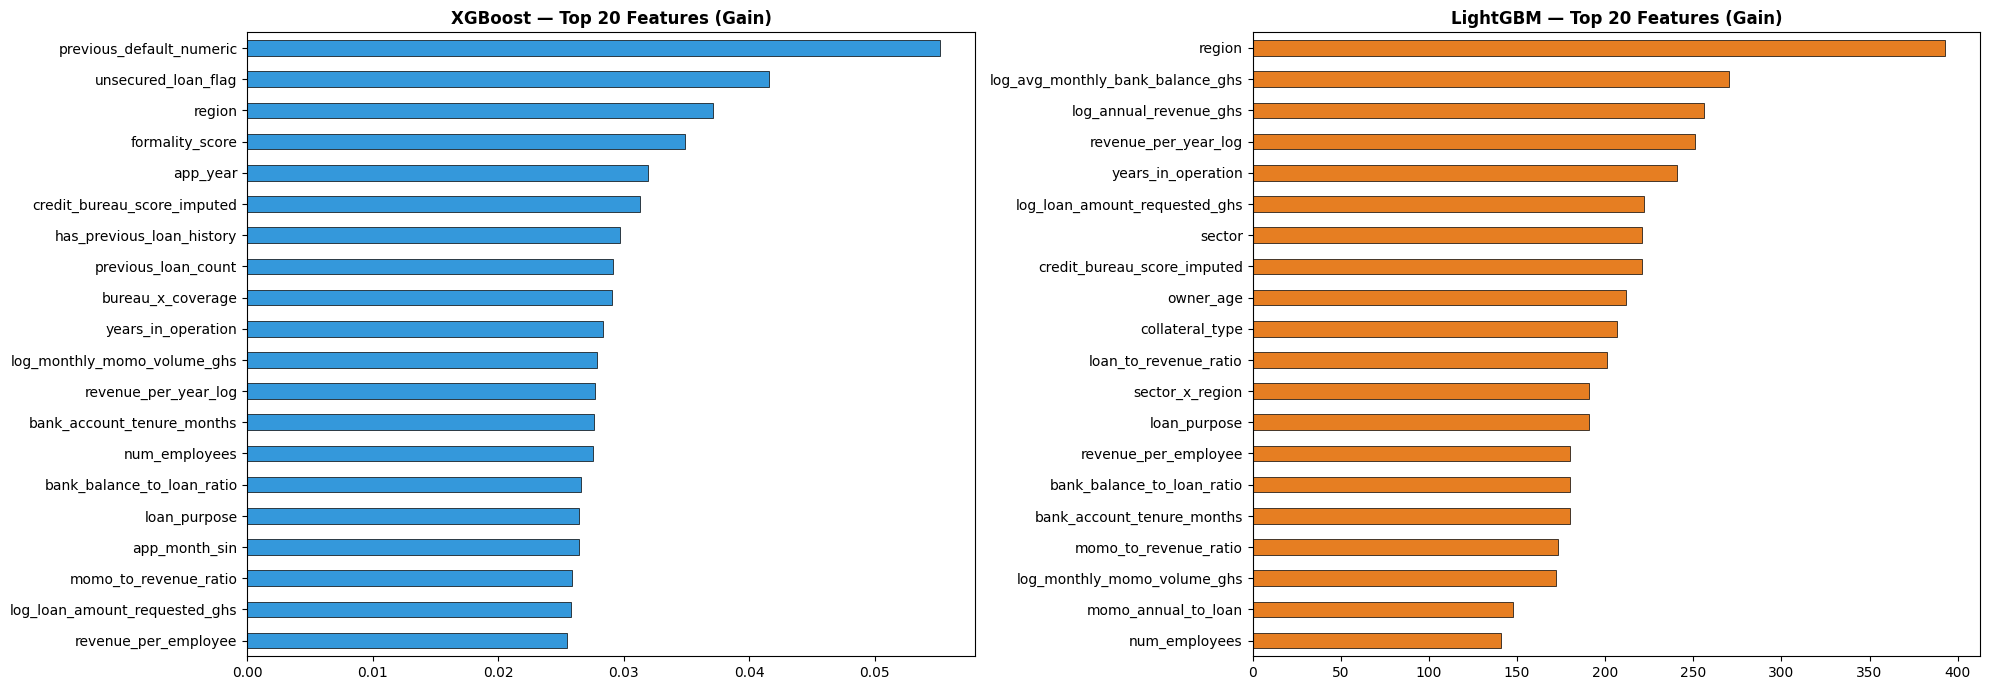

Top 10 (XGBoost):
previous_default_numeric       0.055199
unsecured_loan_flag            0.041567
region                         0.037127
formality_score                0.034891
app_year                       0.031893
credit_bureau_score_imputed    0.031282
has_previous_loan_history      0.029677
previous_loan_count            0.029165
bureau_x_coverage              0.029072
years_in_operation             0.028377

Top 10 (LightGBM):
region                              393
log_avg_monthly_bank_balance_ghs    270
log_annual_revenue_ghs              256
revenue_per_year_log                251
years_in_operation                  241
log_loan_amount_requested_ghs       222
sector                              221
credit_bureau_score_imputed         221
owner_age                           212
collateral_type                     207


In [19]:
# ── CELL 15: Feature importance (XGBoost & LightGBM) ──────────────────────────
# WHY feature names are NUMERIC + CATEGORICAL + BINARY (no OHE expansion):
#   With TargetEncoder, each categorical column produces exactly ONE float output
#   (the mean target rate for that category). No column expansion occurs.
#   So the total output width of the ColumnTransformer equals len(ALL_MODEL_FEATURES).

def get_feature_names_from_pipeline(pipeline):
    # TargetEncoder: 1 output per categorical — no expansion, use names directly
    return NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES

n_plots = 2 if (LGBM_AVAILABLE and best_lgbm) else 1
fig, axes = plt.subplots(1, n_plots, figsize=(10 * n_plots, 7))
if n_plots == 1:
    axes = [axes]

all_names = get_feature_names_from_pipeline(best_xgb)
xgb_imp   = pd.Series(best_xgb.named_steps['classifier'].feature_importances_,
                       index=all_names).sort_values(ascending=False).head(20)
xgb_imp.plot.barh(ax=axes[0], color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].invert_yaxis()
axes[0].set_title('XGBoost — Top 20 Features (Gain)', fontweight='bold')

if LGBM_AVAILABLE and best_lgbm:
    lgbm_imp = pd.Series(best_lgbm.named_steps['classifier'].feature_importances_,
                          index=all_names).sort_values(ascending=False).head(20)
    lgbm_imp.plot.barh(ax=axes[1], color='#e67e22', edgecolor='black', linewidth=0.5)
    axes[1].invert_yaxis()
    axes[1].set_title('LightGBM — Top 20 Features (Gain)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 10 (XGBoost):')
print(xgb_imp.head(10).to_string())
if LGBM_AVAILABLE and best_lgbm:
    print('\nTop 10 (LightGBM):')
    print(lgbm_imp.head(10).to_string())